In [1]:
#Machine Learning: Use the cleaned and processed data to build models for recommendations or trend predictions.

#Step 1: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import NearestNeighbors

# Load the cleaned dataset
file_path = r"C:\Users\Haneefa Ghazi\netflix_titles_updated.csv"
data = pd.read_csv(file_path)



In [4]:
#Step 2: Preprocess the Data

import pandas as pd
import numpy as np

# Load dataset
file_path = r"C:\Users\Haneefa Ghazi\netflix_titles_updated.csv"
data = pd.read_csv(file_path)

# Extract numerical values from 'duration' column
def extract_minutes(duration):
    if pd.isna(duration):  # Handle NaN values
        return np.nan
    elif 'min' in duration:  # If it contains minutes
        return int(duration.replace(' min', ''))
    elif 'Season' in duration:  # If it's a TV Show with seasons
        return int(duration.split(' ')[0]) * 60  # Assuming 1 season = 60 min
    return np.nan  # Unexpected formats

# Apply function to convert duration
data['Duration_Minutes'] = data['duration'].apply(extract_minutes)

# Drop the original 'duration' column
data.drop(columns=['duration'], inplace=True)

# Fill missing values correctly
data.fillna(data.median(numeric_only=True), inplace=True)

# Save cleaned dataset
data.to_csv(r"C:\Users\Haneefa Ghazi\netflix_titles_cleaned.csv", index=False)

print("✅ Data Preprocessing Completed Successfully!")


✅ Data Preprocessing Completed Successfully!


In [5]:
# Drop unnecessary columns
data.drop(['show_id', 'title', 'date_added', 'director', 'country'], axis=1, inplace=True)

# Encode categorical variables
label_encoders = {}
for column in ['type', 'rating', 'listed_in']:
    label_encoders[column] = LabelEncoder()
    data[column] = label_encoders[column].fit_transform(data[column])

# Fill missing values
data.fillna(data.median(), inplace=True)

# Define features (X) and target variable (y)
X = data.drop(['type'], axis=1)  # Features
y = data['type']  # Target (Movie or TV Show)

# Split into training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [6]:
#Step 3: Train a Machine Learning Model

# Train a Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Evaluate model performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.9969662495259765

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1857
           1       0.99      1.00      0.99       780

    accuracy                           1.00      2637
   macro avg       1.00      1.00      1.00      2637
weighted avg       1.00      1.00      1.00      2637


Confusion Matrix:
 [[1851    6]
 [   2  778]]


In [7]:
#Step 4: Build a Recommendation System
        
# Select features for recommendations
features = ['Genre_Count', 'Duration_Minutes', 'rating']
recommendation_data = data[features].fillna(0)

# Normalize data
scaler = StandardScaler()
recommendation_data_scaled = scaler.fit_transform(recommendation_data)

# Train KNN model
knn = NearestNeighbors(n_neighbors=5, metric='euclidean')
knn.fit(recommendation_data_scaled)

# Function to get recommendations
def recommend_movie(index):
    distances, indices = knn.kneighbors([recommendation_data_scaled[index]])
    print("\nRecommended Content Similar to:", data.iloc[index]['listed_in'])
    for idx in indices[0][1:]:
        print("-", data.iloc[idx]['listed_in'], "| Duration:", data.iloc[idx]['Duration_Minutes'], "mins")

# Example: Get recommendations for the first entry
recommend_movie(0)



Recommended Content Similar to: 273
- 65 | Duration: 90 mins
- 184 | Duration: 90 mins
- 273 | Duration: 90 mins
- 512 | Duration: 90 mins


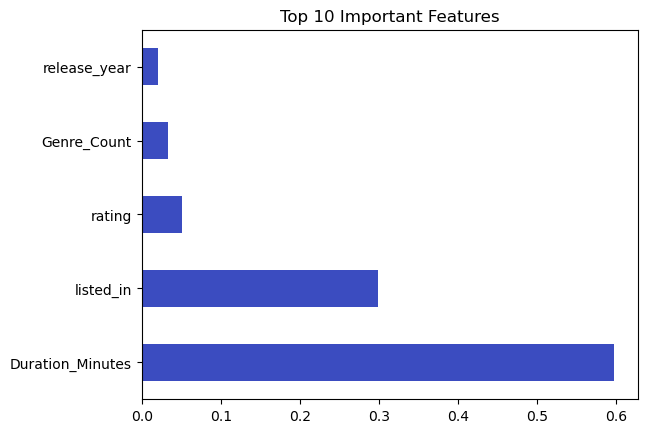

In [8]:
#Step 5: Visualize Feature Importance
# Get feature importances from Random Forest model
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
feature_importances.nlargest(10).plot(kind='barh', colormap='coolwarm')
plt.title('Top 10 Important Features')
plt.show()
